Assignemnt 1.1:
Write Python Behavioral code, verilog RTL code for an AND2 Gate
Write testbench and simulate using iverilog, display waveforms using matplotlib

AND2 Gate

Python Behavioral code

In [1]:
def and2_gate(a: bool, b: bool) -> bool:
    """Behavioral model of a 2-input AND gate."""
    return bool(a and b)

# Example Usage
print("and2_gate(False, False) =", and2_gate(False, False))  # Outputs: False
print("and2_gate(Flase, True) =", and2_gate(False, True))   # Outputs: True
print("and2_gate(True, False) =", and2_gate(True, False))  # Outputs: False
print("and2_gate(True, True) =", and2_gate(True, True))   # Outputs: True


and2_gate(False, False) = False
and2_gate(Flase, True) = False
and2_gate(True, False) = False
and2_gate(True, True) = True


Verilog RTL Code

Install iverilog

In [2]:
# install iverilog
!apt-get update
!apt-get install iverilog

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
iverilog is already the newest version (11.0-1.1).
0 upgraded, 0 newly installed, 0 to remove 

Write RTL and2.v

In [3]:
%%writefile and2.v
module and2 (
    input  wire a,
    input  wire b,
    output wire y
);
    assign y = a & b;
endmodule

Overwriting and2.v


Write Testbench tb_and2.v

In [4]:
%%writefile tb_and2.v
`timescale 1ns / 1ps

module tb_and2;
    reg a;
    reg b;
    wire y;

    and2 uut (
        .a(a),
        .b(b),
        .y(y)
    );

    initial begin
        // --- Added for Waveform Generation ---
        $dumpfile("and2_waveform.vcd");
        $dumpvars(0, tb_and2);
        // -------------------------------------

        $monitor("Time = %0d ns | A = %b | B = %b | Y = %b", $time, a, b, y);

        a = 0; b = 0; #10;
        a = 0; b = 1; #10;
        a = 1; b = 0; #10;
        a = 1; b = 1; #10;

        $finish;
    end
endmodule


Overwriting tb_and2.v


Simulate AND2

In [5]:
!iverilog -o and2_sim and2.v tb_and2.v
!vvp and2_sim


VCD info: dumpfile and2_waveform.vcd opened for output.
Time = 0 ns | A = 0 | B = 0 | Y = 0
Time = 10 ns | A = 0 | B = 1 | Y = 0
Time = 20 ns | A = 1 | B = 0 | Y = 0
Time = 30 ns | A = 1 | B = 1 | Y = 1


Visualize waveform.vcd file using Matplotlib

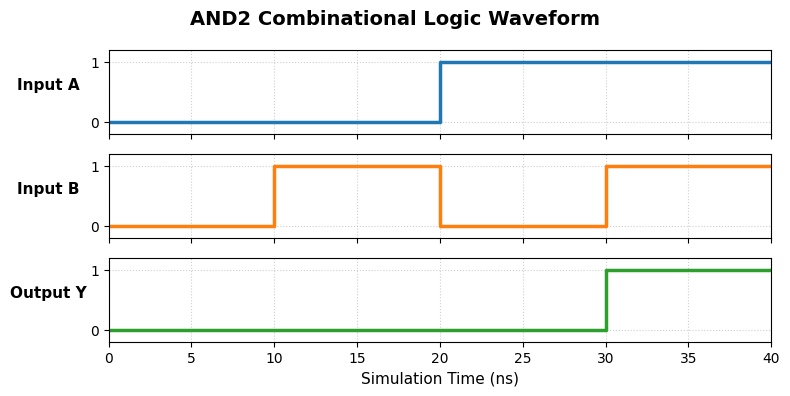

In [6]:
import matplotlib.pyplot as plt

# Define the logical time transitions from our testbench
# Time points: 0ns, 10ns, 20ns, 30ns, 40ns
time_ticks = [0, 10, 20, 30, 40]

# Logic levels derived from the testbench combinations
signal_A = [0, 0, 1, 1, 1]  # Over the duration intervals
signal_B = [0, 1, 0, 1, 1]
signal_Y = [0, 0, 0, 1, 1]

# Set up the plot layout
fig, step_plots = plt.subplots(3, 1, figsize=(8, 4), sharex=True)
fig.suptitle("AND2 Combinational Logic Waveform", fontsize=14, fontweight='bold')

# Configure each digital signal line
signals = [("Input A", signal_A), ("Input B", signal_B), ("Output Y", signal_Y)]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, (name, data) in enumerate(signals):
    # Draw a step function to show instantaneous digital transitions
    step_plots[idx].step(time_ticks, data, where='post', color=colors[idx], linewidth=2.5)

    # Visual grid and boundaries
    step_plots[idx].set_ylabel(name, fontsize=11, fontweight='bold', rotation=0, labelpad=30)
    step_plots[idx].set_ylim(-0.2, 1.2)
    step_plots[idx].set_yticks([0, 1])
    step_plots[idx].grid(True, which='both', linestyle=':', alpha=0.6)

plt.xlabel("Simulation Time (ns)", fontsize=11)
plt.xlim(0, 40)
plt.tight_layout()
plt.show()
